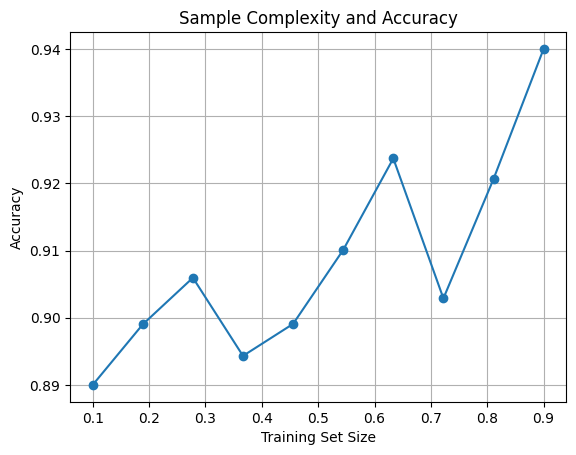

(0.91,
 array([0.1       , 0.18888889, 0.27777778, 0.36666667, 0.45555556,
        0.54444444, 0.63333333, 0.72222222, 0.81111111, 0.9       ]),
 [0.89,
  0.8990147783251231,
  0.9059474412171508,
  0.8943217665615142,
  0.8990825688073395,
  0.9100877192982456,
  0.9237057220708447,
  0.9028776978417267,
  0.9206349206349206,
  0.94])

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(1000, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a decision tree classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Predict on the testing data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Function to evaluate model performance with varying training set sizes
def evaluate_sample_complexity(X, y, test_size=0.2, max_depth=3):
    train_sizes = np.linspace(0.1, 0.9, 10)  # Adjusted to ensure sum with test_size <= 1
    accuracies = []

    for train_size in train_sizes:
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=1-train_size, random_state=42)
        clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)

    return train_sizes, accuracies

# Evaluate sample complexity
train_sizes, accuracies = evaluate_sample_complexity(X, y)

# Plot the results
plt.plot(train_sizes, accuracies, marker='o')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Sample Complexity and Accuracy')
plt.grid(True)
plt.show()

accuracy, train_sizes, accuracies